In [7]:
import numpy as np
import random

# Environment Design

In [14]:
class MatrixGame:
    def __init__(self):
        self.size = 4
        self.action_space = [-2, 1, 2]
        self.reset()

    def reset(self):
        self.board = np.full((self.size, self.size), np.nan)
        self.history = []

        initial_fills = 2
        filled_count = 0
        while filled_count < initial_fills:
            r, c = random.randint(0, 3), random.randint(0, 3)
            if np.isnan(self.board[r, c]):
                self.board[r, c] = random.choice(self.action_space)
                filled_count += 1

        return self.get_state()

    def get_state(self):
        # Convert board to a tuple so it can be hashed in a Q-table
        return tuple(np.nan_to_num(self.board, nan=0.0).flatten())

    def get_empty_cells(self):
        return [(r, c) for r in range(self.size) for c in range(self.size) if np.isnan(self.board[r, c])]

    def check_row_sum_zero(self, board_state):
        # Replace NaNs with 0 temporarily to check row sums of placed numbers
        temp_board = np.nan_to_num(board_state, nan=0.0)
        for i in range(self.size):
            if not np.isnan(board_state[i]).any():
                if np.sum(temp_board[i]) == 0:
                    return True
        return False

    def step(self, action_value):
        empty_cells = self.get_empty_cells()
        if not empty_cells:
            return self.get_state(), 0, True, "Board Full"

        self.history.append(self.board.copy())

        target_cell = empty_cells[0]
        self.board[target_cell] = action_value

        reward = 0
        done = False
        info = ""

        # Check for Rank Deficiency Penalty
        if self.check_row_sum_zero(self.board):
            reward -= 50  # Massive penalty
            self.board = self.history.pop()
            return self.get_state(), reward, False, "Penalty: Row sum became 0. Traced back."

        # Check Win Conditions (Singularity or Board Full)
        if len(self.get_empty_cells()) == 0:
            done = True
            det = np.linalg.det(self.board)
            if abs(det) < 1e-9:
                reward += 100
                info = "Win: Matrix is Singular!"
            else:
                # Dense Reward Shaping: Higher reward the closer determinant is to 0
                shaped_reward = 100 / (abs(det) + 1)
                reward += shaped_reward
                info = f"Game Over: Board Full. Determinant = {det:.2f} | Reward: {shaped_reward:.2f}"

        return self.get_state(), reward, done, info

# Heuristic Agents

In [10]:
def heuristic_agent(env, valid_actions=None):
    """Simple heuristic player. Randomly selects from VALID moves to avoid looping."""
    if valid_actions is None:
        valid_actions = env.action_space
    return random.choice(valid_actions)

# Q-Learning Agent

In [11]:
class QLearningAgent:
    def __init__(self, action_space, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.99997, min_epsilon=0.01):
        self.action_space = action_space
        self.q_table = {}
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

    def get_q(self, state, action):
        # Optimistic Initialization: Encourages deep exploration early on
        return self.q_table.get((state, action), 50.0)

    def choose_action(self, state, valid_actions=None):
        if valid_actions is None or len(valid_actions) == 0:
            valid_actions = self.action_space

        # Exploration vs Exploitation
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(valid_actions)
        else:
            # Exploit only the currently valid actions
            q_values = [self.get_q(state, a) for a in valid_actions]
            max_q = max(q_values)
            best_actions = [a for a, q in zip(valid_actions, q_values) if q == max_q]
            return random.choice(best_actions)

    def learn(self, state, action, reward, next_state, done):
        current_q = self.get_q(state, action)

        if done:
            max_future_q = 0
        else:
            max_future_q = max([self.get_q(next_state, a) for a in self.action_space])

        # The Bellman Equation / TD Error
        td_error = (reward + self.gamma * max_future_q) - current_q
        self.q_table[(state, action)] = current_q + self.alpha * td_error

        return abs(td_error) # Return error for potential tracking

    def decay_epsilon(self):
        if self.epsilon > self.min_epsilon:
            self.epsilon *= self.epsilon_decay

# Tranining Phase

In [15]:
env = MatrixGame()
agent = QLearningAgent(action_space=env.action_space)

episodes = 200000
print(f"Training started for {episodes} episodes...")

for episode in range(episodes):
    state = env.reset()
    done = False
    episode_memory = []

    while not done:
        action = agent.choose_action(state)
        next_state, reward, done, info = env.step(action)

        episode_memory.append((state, action, reward, next_state, done))
        state = next_state

    # Queue Learning / Prioritized Experience Replay
    episode_memory.sort(key=lambda transition: abs(transition[2]), reverse=True)

    for (s, a, r, n_s, d) in episode_memory:
        agent.learn(s, a, r, n_s, d)

    agent.decay_epsilon()

    if (episode + 1) % 10000 == 0:
        print(f"Episode {episode + 1} completed. Exploration rate: {agent.epsilon:.3f}")

print("\nTraining complete! Total state-action pairs learned:", len(agent.q_table))

Training started for 200000 episodes...
Episode 10000 completed. Exploration rate: 0.741
Episode 20000 completed. Exploration rate: 0.549
Episode 30000 completed. Exploration rate: 0.407
Episode 40000 completed. Exploration rate: 0.301
Episode 50000 completed. Exploration rate: 0.223
Episode 60000 completed. Exploration rate: 0.165
Episode 70000 completed. Exploration rate: 0.122
Episode 80000 completed. Exploration rate: 0.091
Episode 90000 completed. Exploration rate: 0.067
Episode 100000 completed. Exploration rate: 0.050
Episode 110000 completed. Exploration rate: 0.037
Episode 120000 completed. Exploration rate: 0.027
Episode 130000 completed. Exploration rate: 0.020
Episode 140000 completed. Exploration rate: 0.015
Episode 150000 completed. Exploration rate: 0.011
Episode 160000 completed. Exploration rate: 0.010
Episode 170000 completed. Exploration rate: 0.010
Episode 180000 completed. Exploration rate: 0.010
Episode 190000 completed. Exploration rate: 0.010
Episode 200000 comp

# Evaluation

In [16]:
# Turn off exploration for the actual game
agent.epsilon = 0
state = env.reset()
done = False

scores = {"RL_Agent": 0, "Heuristic": 0}
banned_actions = []

print("--- THE SHOWDOWN: RL Agent vs Heuristic Agent ⚔️ ---")
print("Initial Board:\n", env.board)

turn = 1
current_player = "RL_Agent"

while not done:
    # Filter out actions that caused a traceback on this specific turn
    valid_actions = [a for a in env.action_space if a not in banned_actions]

    if not valid_actions:
        print(f"\n{current_player} is mathematically trapped! All moves cause a penalty. Game Over.")
        break

    if current_player == "RL_Agent":
        action = agent.choose_action(state, valid_actions=valid_actions)
    else:
        action = heuristic_agent(env, valid_actions=valid_actions)

    state, reward, done, info = env.step(action)
    scores[current_player] += reward

    print(f"\nTurn {turn} | {current_player} placed: {action} | Earned Reward: {reward:.2f}")

    if info:
        print(f"Status Update: {info}")

    # Short-Term Memory Logic
    if "Traced back" in info:
        banned_actions.append(action)
    else:
        banned_actions = []
        current_player = "Heuristic" if current_player == "RL_Agent" else "RL_Agent"
        turn += 1

print("\n" + "="*30)
print("MATCH COMPLETE")
print("="*30)
print("Final Board:\n", env.board)
print(f"RL Agent Final Score:  {scores['RL_Agent']:.2f}")
print(f"Heuristic Final Score: {scores['Heuristic']:.2f}")
print("-" * 30)

if scores['RL_Agent'] > scores['Heuristic']:
    print("WINNER: Reinforcement Learning Agent!")
elif scores['Heuristic'] > scores['RL_Agent']:
    print("WINNER: Heuristic Player!")
else:
    print("RESULT: It's a Tie!")

--- THE SHOWDOWN: RL Agent vs Heuristic Agent ⚔️ ---
Initial Board:
 [[nan nan nan nan]
 [nan nan nan nan]
 [nan nan  2. nan]
 [nan nan -2. nan]]

Turn 1 | RL_Agent placed: -2 | Earned Reward: 0.00

Turn 2 | Heuristic placed: 2 | Earned Reward: 0.00

Turn 3 | RL_Agent placed: -2 | Earned Reward: 0.00

Turn 4 | Heuristic placed: -2 | Earned Reward: 0.00

Turn 5 | RL_Agent placed: 2 | Earned Reward: 0.00

Turn 6 | Heuristic placed: 2 | Earned Reward: 0.00

Turn 7 | RL_Agent placed: 1 | Earned Reward: 0.00

Turn 8 | Heuristic placed: 2 | Earned Reward: 0.00

Turn 9 | RL_Agent placed: -2 | Earned Reward: 0.00

Turn 10 | Heuristic placed: 1 | Earned Reward: 0.00

Turn 11 | RL_Agent placed: 1 | Earned Reward: 0.00

Turn 12 | Heuristic placed: 2 | Earned Reward: 0.00

Turn 13 | RL_Agent placed: 1 | Earned Reward: 0.00

Turn 14 | Heuristic placed: -2 | Earned Reward: 2.33
Status Update: Game Over: Board Full. Determinant = 42.00 | Reward: 2.33

🏁 MATCH COMPLETE 🏁
Final Board:
 [[-2.  2. -2. -2

In [17]:
import pickle

# Save the Q-table to a file
with open('matrix_q_table.pkl', 'wb') as f:
    pickle.dump(agent.q_table, f)

print("Model saved successfully as 'matrix_q_table.pkl'")

Model saved successfully as 'matrix_q_table.pkl'


In [18]:
import pickle

env = MatrixGame()
trained_agent = QLearningAgent(action_space=env.action_space)

with open('matrix_q_table.pkl', 'rb') as f:
    loaded_q_table = pickle.load(f)

trained_agent.q_table = loaded_q_table
trained_agent.epsilon = 0

print(f"Model loaded! {len(trained_agent.q_table)} state-action pairs ready to go.")

Model loaded! 1932331 state-action pairs ready to go.


# Animated Gameplay

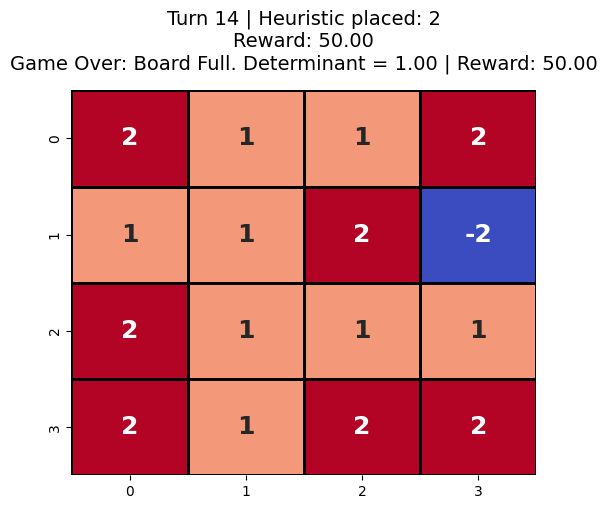


RL Agent Final Score:  0.00
Heuristic Final Score: 50.00
WINNER: Heuristic Player!


In [19]:
import time
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import seaborn as sns

# Animated Game Replay
agent.epsilon = 0
state = env.reset()
done = False

scores = {"RL_Agent": 0, "Heuristic": 0}
banned_actions = []
turn = 1
current_player = "RL_Agent"

while not done:
    valid_actions = [a for a in env.action_space if a not in banned_actions]

    if not valid_actions:
        print(f"\n{current_player} is mathematically trapped! Game Over.")
        break

    if current_player == "RL_Agent":
        action = agent.choose_action(state, valid_actions=valid_actions)
    else:
        action = heuristic_agent(env, valid_actions=valid_actions)

    state, reward, done, info = env.step(action)
    scores[current_player] += reward

    clear_output(wait=True)

    plt.figure(figsize=(6, 5))

    sns.heatmap(env.board, annot=True, cmap="coolwarm", center=0,
                cbar=False, linewidths=2, linecolor='black',
                annot_kws={"size": 18, "weight": "bold"})

    status_text = f"Turn {turn} | {current_player} placed: {action}\nReward: {reward:.2f}"
    if info:
        status_text += f"\n{info}"

    plt.title(status_text, fontsize=14, pad=15)
    plt.show()

    time.sleep(1.0)

    if "Traced back" in info:
        banned_actions.append(action)
    else:
        banned_actions = []
        current_player = "Heuristic" if current_player == "RL_Agent" else "RL_Agent"
        turn += 1

# --- Declare the Winner at the End ---
print("\n" + "="*30)
print(f"RL Agent Final Score:  {scores['RL_Agent']:.2f}")
print(f"Heuristic Final Score: {scores['Heuristic']:.2f}")

if scores['RL_Agent'] > scores['Heuristic']:
    print("WINNER: Reinforcement Learning Agent!")
elif scores['Heuristic'] > scores['RL_Agent']:
    print("WINNER: Heuristic Player!")
else:
    print("RESULT: It's a Tie!")